In [ ]:
!pip install bayesian-optimization

In [ ]:
import pandas as pd
import torch
import os
import numpy as np
from bayes_opt import BayesianOptimization
import matplotlib.pyplot as plt
from datetime import datetime
import json
import pickle
import os
from collections import defaultdict, Counter
from sklearn.linear_model import LogisticRegression
from sklearn.isotonic import IsotonicRegression


In [ ]:
base = '/content/drive/MyDrive/data/B'

In [ ]:
train_data = pd.read_csv(os.path.join(base, 'train.csv'))
test_data = pd.read_csv(os.path.join(base, 'test.csv'))

In [ ]:
train_data['C'] = train_data['C'].map({'-': 0, '+': 1})
test_data['C'] = test_data['C'].map({'-': 0, '+': 1})

In [ ]:
train_data['E'].isnull().sum()

np.int64(75)

In [ ]:
X = train_data.drop('target', axis=1).to_numpy()
y = train_data['target'].to_numpy()
X_test = test_data.to_numpy()
class_weights = [len(y) / (2 * (len(y) - y.sum())), len(y) / (2 * y.sum())]
print(class_weights)

[np.float64(0.702247191011236), np.float64(1.7361111111111112)]


In [ ]:
from sklearn.preprocessing import StandardScaler # нужно масштабирование
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.metrics import roc_auc_score
from sklearn.calibration import CalibratedClassifierCV, calibration_curve
from sklearn.metrics import brier_score_loss, roc_auc_score
import matplotlib.pyplot as plt

# Логистическая регрессия (26 баллов)

In [ ]:
def logreg(train_data):
    df = train_data.copy()
    df['E'] = df['E'].fillna(0)

    # df['E'] = df['E'].astype('category')
    # df['E'] = df['E'].cat.add_categories('missing')
    # df['E'] = df['E'].fillna('missing')
    # df_ohe = pd.get_dummies(df['E'], prefix='E')
    # df = df.drop('E', axis=1)
    # df = pd.concat([df, df_ohe], axis=1)



    X = df.drop('target', axis=1).to_numpy()
    y = df['target'].to_numpy()

    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.1, random_state=42, stratify=y
    )

    penalties = ['none', 'l1', 'l2', 'elasticnet']
    solvers = {
        'none': 'lbfgs',       # имитируем "нет регуляризации" через очень большой C
        'l2': 'lbfgs',
        'l1': 'saga',
        'elasticnet': 'saga'
    }

    results = []

    # широкая сетка C для эксперимента
    Cs_grid = np.logspace(-4, 4, 10)

    for penalty in penalties:
        solver = solvers[penalty]
        l1_ratios = [.5] if penalty == 'elasticnet' else None
        Cs = [1e12] if penalty == 'none' else Cs_grid
        actual_penalty = 'l2' if penalty == 'none' else penalty

        print(f"\n=== Penalty: {penalty}, Solver: {solver} ===")
        clf = make_pipeline(
            StandardScaler(),
            LogisticRegressionCV(
                penalty=actual_penalty,
                solver=solver,
                Cs=Cs,
                cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42),
                scoring='roc_auc',
                class_weight='balanced',
                max_iter=1000,
                l1_ratios=l1_ratios,
                random_state=42,
                refit=True
            )
        )

        clf.fit(X_train, y_train)
        logloss_train = log_loss(y_train, clf.predict_proba(X_train)[:,1])
        auc_test = roc_auc_score(y_test, clf.predict_proba(X_test)[:,1])

        # логируем детали
        print(f"Train log-loss: {logloss_train:.4f}, Test ROC AUC: {auc_test:.4f}")
        print(f"Best C(s): {clf.named_steps['logisticregressioncv'].C_}")
        if penalty == 'elasticnet':
            print(f"Best l1_ratio(s): {clf.named_steps['logisticregressioncv'].l1_ratio_}")

        results.append({
            'penalty': penalty,
            'solver': solver,
            'auc_test': auc_test,
            'logloss_train': logloss_train,
            'best_C': clf.named_steps['logisticregressioncv'].C_,
            'best_l1_ratio': clf.named_steps['logisticregressioncv'].l1_ratio_ if penalty=='elasticnet' else None,
            'pipeline': clf
        })

    results_sorted = sorted(results, key=lambda x: x['auc_test'], reverse=True)
    print('Best auc:', results_sorted[0]['auc_test'])
    return results_sorted


def logreg_with_calibration_plot(train_data):
    results_sorted = logreg(train_data)

    best_clf = results_sorted[0]['pipeline']

    df = train_data.copy()
    df['E'] = df['E'].fillna(0)

    X = df.drop('target', axis=1).to_numpy()
    y = df['target'].to_numpy()

    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.1, random_state=42, stratify=y
    )

    y_prob = best_clf.predict_proba(X_test)[:, 1]

    prob_true, prob_pred = calibration_curve(y_test, y_prob, n_bins=10)

    plt.figure(figsize=(6,6))
    plt.plot(prob_pred, prob_true, marker='o', label='Model')
    plt.plot([0,1], [0,1], linestyle='--', color='gray', label='Perfectly calibrated')

    plt.xlabel('Predicted probability')
    plt.ylabel('True probability')
    plt.title('Calibration plot (Test set)')
    plt.legend()
    plt.grid(True)
    plt.show()

    return results_sorted


=== Penalty: none, Solver: lbfgs ===
Train log-loss: 0.5026, Test ROC AUC: 0.8368
Best C(s): [1.e+12]

=== Penalty: l1, Solver: saga ===
Train log-loss: 0.5031, Test ROC AUC: 0.8373
Best C(s): [0.35938137]

=== Penalty: l2, Solver: lbfgs ===
Train log-loss: 0.5074, Test ROC AUC: 0.8324
Best C(s): [0.04641589]

=== Penalty: elasticnet, Solver: saga ===
Train log-loss: 0.5099, Test ROC AUC: 0.8426
Best C(s): [0.04641589]
Best l1_ratio(s): [0.5]
Best auc: 0.842642059252064


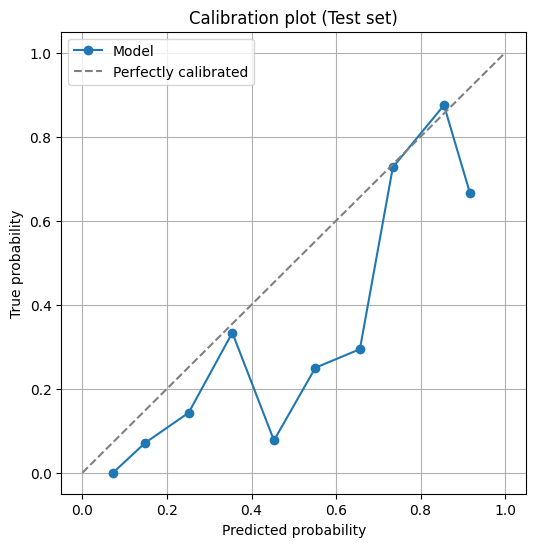

In [ ]:
res = logreg_with_calibration_plot(train_data)

## Попробуем калибровку

In [ ]:
res[0]['pipeline']

Pipeline(steps=[('standardscaler', StandardScaler()),
                ('logisticregressioncv',
                 LogisticRegressionCV(Cs=array([1.00000000e-04, 7.74263683e-04, 5.99484250e-03, 4.64158883e-02,
       3.59381366e-01, 2.78255940e+00, 2.15443469e+01, 1.66810054e+02,
       1.29154967e+03, 1.00000000e+04]),
                                      class_weight='balanced',
                                      cv=StratifiedKFold(n_splits=5, random_state=42, shuffle=True),
                                      l1_ratios=[0.5], max_iter=1000,
                                      penalty='elasticnet', random_state=42,
                                      scoring='roc_auc', solver='saga'))])

In [ ]:


def try_calibrate_logreg(train_data):
    results_sorted = logreg(train_data)
    best_pipeline = results_sorted[0]['pipeline']
    scaler = best_pipeline.named_steps['standardscaler']
    model = best_pipeline.named_steps['logisticregressioncv']

    print('AUC before calibration (test set):', results_sorted[0]['auc_test'])

    df = train_data.copy()
    df['E'] = df['E'].fillna(0)

    X = df.drop('target', axis=1).to_numpy()
    y = df['target'].to_numpy()

    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.1, random_state=42, stratify=y
    )
    X_train, X_test = scaler.transform(X_train), scaler.transform(X_test)

    # Brier score до калибровки
    y_prob_before = model.predict_proba(X_test)[:,1]
    brier_before = brier_score_loss(y_test, y_prob_before)
    print(f"Brier score before calibration: {brier_before:.4f}")

    # калибровка
    calibrated_clf = CalibratedClassifierCV(estimator=model, method='isotonic', cv='prefit')
    calibrated_clf.fit(X_train, y_train)

    y_prob_after = calibrated_clf.predict_proba(X_test)[:,1]

    # метрики после калибровки
    brier_after = brier_score_loss(y_test, y_prob_after)
    auc_after = roc_auc_score(y_test, y_prob_after)
    print(f"Brier score after calibration: {brier_after:.4f}")
    print(f"ROC AUC after calibration: {auc_after:.4f}")

    # калибровочная кривая
    prob_true, prob_pred = calibration_curve(y_test, y_prob_after, n_bins=10)

    plt.figure(figsize=(6,6))
    plt.plot(prob_pred, prob_true, marker='o', label='Calibrated model')
    plt.plot([0,1], [0,1], linestyle='--', color='gray', label='Perfectly calibrated')
    plt.xlabel('Predicted probability')
    plt.ylabel('True probability')
    plt.title('Calibration plot (Test set)')
    plt.legend()
    plt.grid(True)
    plt.show()

    return calibrated_clf



=== Penalty: none, Solver: lbfgs ===
Train log-loss: 0.5026, Test ROC AUC: 0.8368
Best C(s): [1.e+12]

=== Penalty: l1, Solver: saga ===
Train log-loss: 0.5031, Test ROC AUC: 0.8373
Best C(s): [0.35938137]

=== Penalty: l2, Solver: lbfgs ===
Train log-loss: 0.5074, Test ROC AUC: 0.8324
Best C(s): [0.04641589]

=== Penalty: elasticnet, Solver: saga ===
Train log-loss: 0.5099, Test ROC AUC: 0.8426
Best C(s): [0.04641589]
Best l1_ratio(s): [0.5]
Best auc: 0.842642059252064
AUC before calibration (test set): 0.842642059252064
Brier score before calibration: 0.1807
Brier score after calibration: 0.1462
ROC AUC after calibration: 0.8395


/usr/local/lib/python3.12/dist-packages/sklearn/calibration.py:333: UserWarning: The `cv='prefit'` option is deprecated in 1.6 and will be removed in 1.8. You can use CalibratedClassifierCV(FrozenEstimator(estimator)) instead.
  warnings.warn(


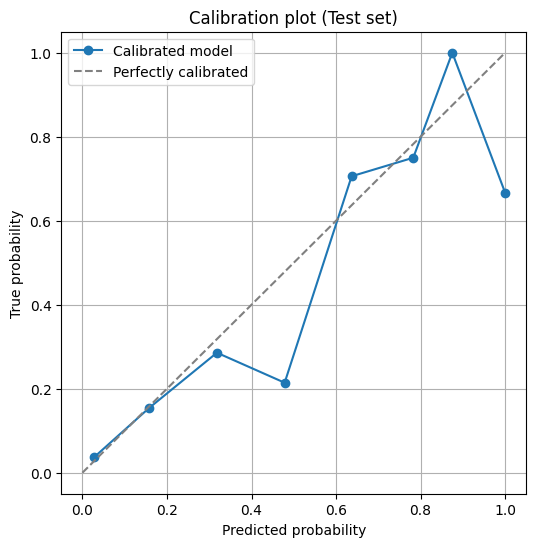

CalibratedClassifierCV(cv='prefit',
                       estimator=LogisticRegressionCV(Cs=array([1.00000000e-04, 7.74263683e-04, 5.99484250e-03, 4.64158883e-02,
       3.59381366e-01, 2.78255940e+00, 2.15443469e+01, 1.66810054e+02,
       1.29154967e+03, 1.00000000e+04]),
                                                      class_weight='balanced',
                                                      cv=StratifiedKFold(n_splits=5, random_state=42, shuffle=True),
                                                      l1_ratios=[0.5],
                                                      max_iter=1000,
                                                      penalty='elasticnet',
                                                      random_state=42,
                                                      scoring='roc_auc',
                                                      solver='saga'),
                       method='isotonic')

In [ ]:
try_calibrate_logreg(train_data)

In [ ]:
def logreg_calibrated(train_data):
    df = train_data.copy()
    df['E'] = df['E'].fillna(0)

    X = df.drop('target', axis=1).to_numpy()
    y = df['target'].to_numpy()

    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.1, random_state=42, stratify=y
    )

    penalties = ['none', 'l1', 'l2', 'elasticnet']
    solvers = {'none':'lbfgs', 'l2':'lbfgs', 'l1':'saga', 'elasticnet':'saga'}
    calibration_methods = ['isotonic', 'sigmoid']

    results = []
    Cs_grid = np.logspace(-4, 4, 10)

    for penalty in penalties:
        solver = solvers[penalty]
        l1_ratios = [.5] if penalty=='elasticnet' else None
        Cs = [1e12] if penalty=='none' else Cs_grid
        actual_penalty = 'l2' if penalty=='none' else penalty

        for calib_method in calibration_methods:
            print(f"\n=== Penalty: {penalty}, Solver: {solver}, Calibration: {calib_method} ===")

            base_clf = make_pipeline(
                StandardScaler(),
                LogisticRegressionCV(
                    penalty=actual_penalty,
                    solver=solver,
                    Cs=Cs,
                    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42),
                    scoring='roc_auc',
                    class_weight='balanced',
                    max_iter=1000,
                    l1_ratios=l1_ratios,
                    random_state=42,
                    refit=True
                )
            )

            calibrated_clf = CalibratedClassifierCV(base_clf, method=calib_method, cv=5)
            calibrated_clf.fit(X_train, y_train)

            y_prob_train = calibrated_clf.predict_proba(X_train)[:,1]
            y_prob_test = calibrated_clf.predict_proba(X_test)[:,1]

            logloss_train = log_loss(y_train, y_prob_train)
            auc_test = roc_auc_score(y_test, y_prob_test)
            print(f"Train log-loss: {logloss_train:.4f}, Test ROC AUC: {auc_test:.4f}")

            base_model = calibrated_clf.estimator.named_steps['logisticregressioncv']
            best_C = base_model.Cs
            best_l1_ratio = base_model.l1_ratios if penalty=='elasticnet' else None
            if penalty=='elasticnet':
                print(f"Best l1_ratio(s): {best_l1_ratio}")
            print(f"Best C(s): {best_C}")

            # калибровочная кривая
            prob_true, prob_pred = calibration_curve(y_test, y_prob_test, n_bins=10)
            plt.figure(figsize=(6,6))
            plt.plot(prob_pred, prob_true, marker='o', label=f'{penalty} + {calib_method}')
            plt.plot([0,1], [0,1], linestyle='--', color='gray')
            plt.xlabel('Predicted probability')
            plt.ylabel('True probability')
            plt.title(f'Calibration plot ({penalty} + {calib_method})')
            plt.grid(True)
            plt.show()

            results.append({
                'penalty': penalty,
                'solver': solver,
                'calibration': calib_method,
                'auc_test': auc_test,
                'logloss_train': logloss_train,
                'best_C': best_C,
                'best_l1_ratio': best_l1_ratio,
                'pipeline': calibrated_clf
            })

    results_sorted = sorted(results, key=lambda x: x['auc_test'], reverse=True)
    print('Best overall AUC:', results_sorted[0]['auc_test'])
    return results_sorted


=== Penalty: none, Solver: lbfgs, Calibration: isotonic ===
Train log-loss: 0.4310, Test ROC AUC: 0.8346
Best C(s): [1000000000000.0]


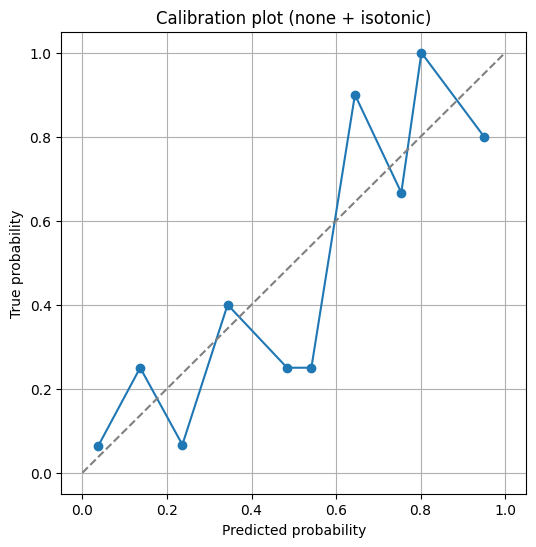


=== Penalty: none, Solver: lbfgs, Calibration: sigmoid ===
Train log-loss: 0.4409, Test ROC AUC: 0.8368
Best C(s): [1000000000000.0]


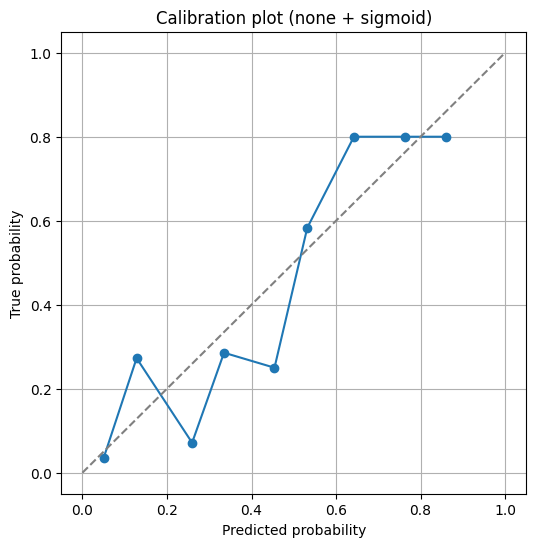


=== Penalty: l1, Solver: saga, Calibration: isotonic ===
Train log-loss: 0.4304, Test ROC AUC: 0.8368
Best C(s): [1.00000000e-04 7.74263683e-04 5.99484250e-03 4.64158883e-02
 3.59381366e-01 2.78255940e+00 2.15443469e+01 1.66810054e+02
 1.29154967e+03 1.00000000e+04]


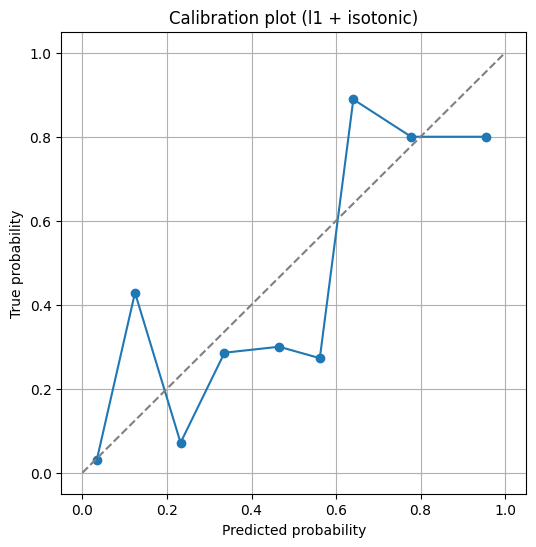


=== Penalty: l1, Solver: saga, Calibration: sigmoid ===
Train log-loss: 0.4412, Test ROC AUC: 0.8388
Best C(s): [1.00000000e-04 7.74263683e-04 5.99484250e-03 4.64158883e-02
 3.59381366e-01 2.78255940e+00 2.15443469e+01 1.66810054e+02
 1.29154967e+03 1.00000000e+04]


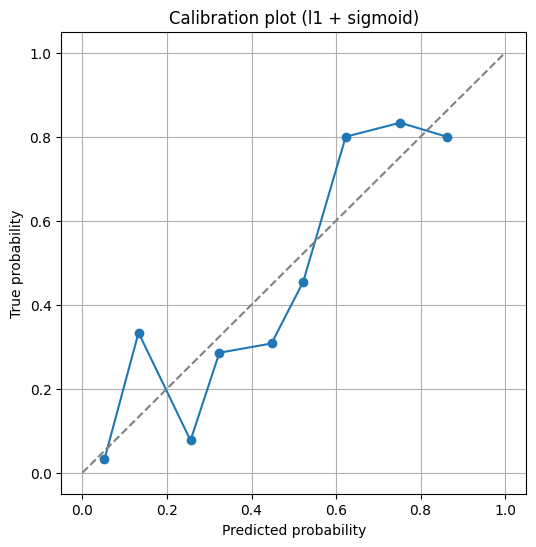


=== Penalty: l2, Solver: lbfgs, Calibration: isotonic ===
Train log-loss: 0.4312, Test ROC AUC: 0.8361
Best C(s): [1.00000000e-04 7.74263683e-04 5.99484250e-03 4.64158883e-02
 3.59381366e-01 2.78255940e+00 2.15443469e+01 1.66810054e+02
 1.29154967e+03 1.00000000e+04]


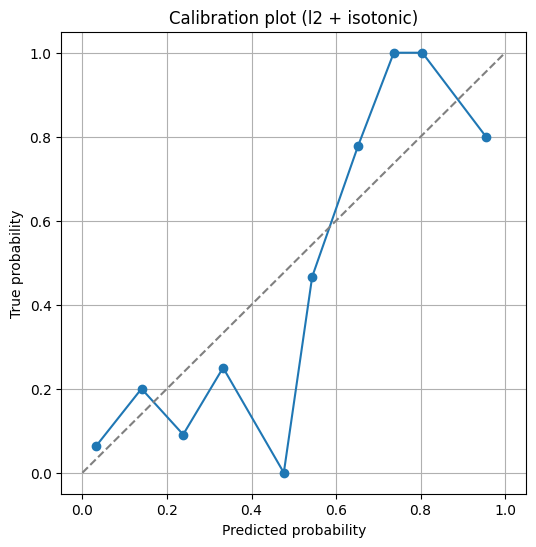


=== Penalty: l2, Solver: lbfgs, Calibration: sigmoid ===
Train log-loss: 0.4412, Test ROC AUC: 0.8358
Best C(s): [1.00000000e-04 7.74263683e-04 5.99484250e-03 4.64158883e-02
 3.59381366e-01 2.78255940e+00 2.15443469e+01 1.66810054e+02
 1.29154967e+03 1.00000000e+04]


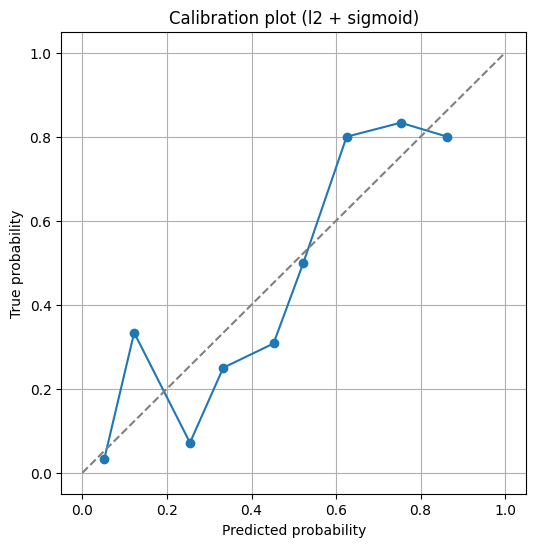


=== Penalty: elasticnet, Solver: saga, Calibration: isotonic ===
Train log-loss: 0.4347, Test ROC AUC: 0.8378
Best l1_ratio(s): [0.5]
Best C(s): [1.00000000e-04 7.74263683e-04 5.99484250e-03 4.64158883e-02
 3.59381366e-01 2.78255940e+00 2.15443469e+01 1.66810054e+02
 1.29154967e+03 1.00000000e+04]


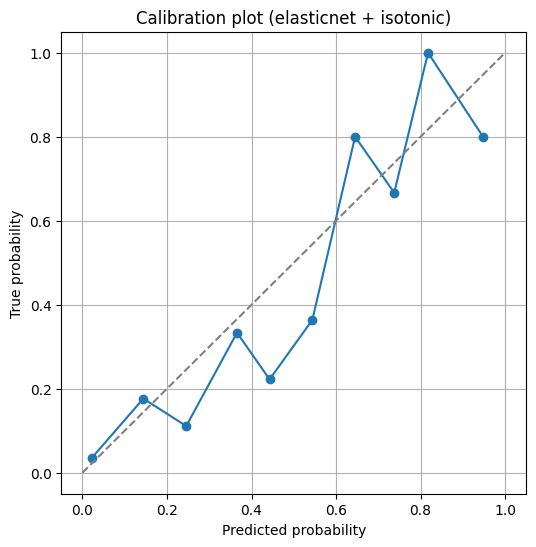


=== Penalty: elasticnet, Solver: saga, Calibration: sigmoid ===
Train log-loss: 0.4424, Test ROC AUC: 0.8422
Best l1_ratio(s): [0.5]
Best C(s): [1.00000000e-04 7.74263683e-04 5.99484250e-03 4.64158883e-02
 3.59381366e-01 2.78255940e+00 2.15443469e+01 1.66810054e+02
 1.29154967e+03 1.00000000e+04]


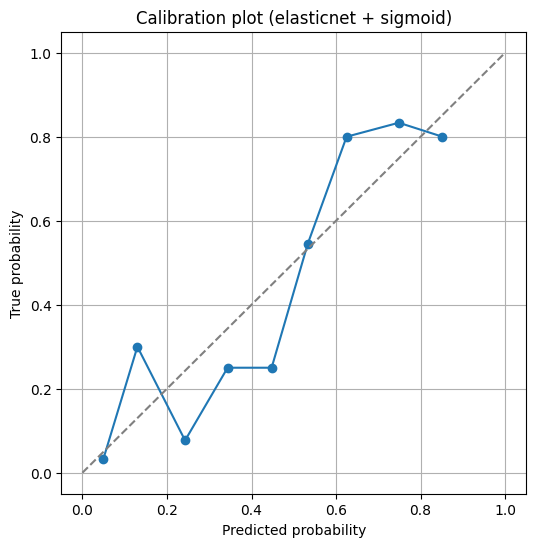

Best overall AUC: 0.8421563865954347


In [ ]:
res2 = logreg_calibrated(train_data)

In [ ]:
def infer_logreg(results, train_data, test_data):
    pipeline = results[0]['pipeline']

    X, y = train_data.drop('target', axis=1).to_numpy(), train_data['target'].to_numpy()
    X_test = test_data.to_numpy()

print(res2[0])


{'penalty': 'elasticnet', 'solver': 'saga', 'calibration': 'sigmoid', 'auc_test': np.float64(0.8421563865954347), 'logloss_train': 0.44239842536252927, 'best_C': array([1.00000000e-04, 7.74263683e-04, 5.99484250e-03, 4.64158883e-02,
       3.59381366e-01, 2.78255940e+00, 2.15443469e+01, 1.66810054e+02,
       1.29154967e+03, 1.00000000e+04]), 'best_l1_ratio': [0.5], 'pipeline': CalibratedClassifierCV(cv=5,
                       estimator=Pipeline(steps=[('standardscaler',
                                                  StandardScaler()),
                                                 ('logisticregressioncv',
                                                  LogisticRegressionCV(Cs=array([1.00000000e-04, 7.74263683e-04, 5.99484250e-03, 4.64158883e-02,
       3.59381366e-01, 2.78255940e+00, 2.15443469e+01, 1.66810054e+02,
       1.29154967e+03, 1.00000000e+04]),
                                                                       class_weight='balanced',
                          

## инфер

In [ ]:
res[0]['best_l1_ratio']

array([0.5])

In [ ]:
from sklearn.impute import SimpleImputer

def logreg_infer(train_data, test_data, best_params):
    """
    train_data: DataFrame с признаками + 'target'
    test_data: DataFrame с признаками (без target)
    best_params: словарь из результатов логрегрессии, например results_sorted[0]
    """
    # извлекаем параметры модели
    penalty = best_params['penalty']
    solver = best_params['solver']
    C = best_params['best_C'][0] if isinstance(best_params['best_C'], (list, np.ndarray)) else best_params['best_C']
    l1_ratio = best_params['best_l1_ratio'][0] if best_params['best_l1_ratio'] is not None else None

    # для 'none' имитируем через очень большой C
    actual_penalty = 'l2' if penalty == 'none' else penalty
    C = 1e12 if penalty == 'none' else C

    # создаём пайплайн с обработкой пропусков
    clf = make_pipeline(
        SimpleImputer(strategy='constant', fill_value=0),  # заполняем пропуски нулями
        StandardScaler(),
        LogisticRegression(
            penalty=actual_penalty,
            solver=solver,
            C=C,
            class_weight='balanced',
            max_iter=1000,
            l1_ratio=l1_ratio,
            random_state=42
        )
    )

    X_train = train_data.drop('target', axis=1)
    y_train = train_data['target'].to_numpy()
    X_test = test_data

    clf.fit(X_train, y_train)
    y_pred = clf.predict_proba(X_test)[:,1]  # вероятности класса 1

    return pd.DataFrame({'target': y_pred})


In [ ]:
answer = logreg_infer(train_data, test_data, res[0])

In [ ]:
answer.to_csv('answers.csv', index=False)

# Бустинг (97 баллов с усреднением предсказаний, 100 баллов - с одной моделью)

In [ ]:
!pip install catboost

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 99.2/99.2 MB 7.6 MB/s eta 0:00:00


In [ ]:
from catboost import CatBoostClassifier, Pool
from sklearn.base import BaseEstimator, ClassifierMixin

In [ ]:
def try_catboost(train_data, FOLD_CHECKPOINTS=None, base='./checkpoints'):
    # Создаем директорию для чекпойнтов
    os.makedirs(base, exist_ok=True)
    checkpoint_path = os.path.join(base, 'catboost_checkpoint.pkl')

    try:
        df = train_data.copy()
        X = df.drop('target', axis=1).to_numpy()
        n_features = X.shape[1]
        y = df['target'].to_numpy()

        # Разделение на train/test (test не трогаем до финала)
        X_train, X_test, y_train, y_test = train_test_split(
            X, y, test_size=0.1, shuffle=True, random_state=42
        )

        kf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

        if FOLD_CHECKPOINTS is None:
            # ЕСЛИ ЕСТЬ FOLD_CHECKPOINTS, ТО ПОИСК ЛУЧШИХ ГИПЕРПАРАМЕТРОВ НЕ НУЖЕН
            # Конфигурация поиска
            losses = ['Logloss', 'CrossEntropy']
            grow_policies = ['SymmetricTree', 'Lossguide', 'Depthwise']

            best_score = -np.inf
            best_config = None

            # Счетчики для логирования прогресса
            total_iterations = len(losses) * len(grow_policies) * kf.get_n_splits()
            current_iteration = 0

            print(f"Начало оптимизации: {datetime.now().strftime('%H:%M:%S')}")
            print(f"Всего конфигураций: {total_iterations}")
            print(f"Количество признаков: {n_features}")
            print(f"RSM диапазон: [{1 / (n_features ** 0.5):.3f}, 1.0]")
            print("-" * 80)

            # Кросс-валидация
            FOLD_CHECKPOINTS = []
            for fold_idx, (train_idx, val_idx) in enumerate(kf.split(X_train)):
                # Создаем fold из X_train/y_train
                X_fold_train, X_fold_val = X_train[train_idx], X_train[val_idx]
                y_fold_train, y_fold_val = y_train[train_idx], y_train[val_idx]

                train_pool = Pool(X_fold_train, y_fold_train)
                val_pool = Pool(X_fold_val, y_fold_val)

                fold_best_score = -np.inf
                fold_best_params = None
                fold_best_config = None

                for loss_func in losses:
                    for grow_policy in grow_policies:
                        current_iteration += 1

                        print(f"\n[{current_iteration}/{total_iterations}] "
                              f"Fold {fold_idx+1}/5 | Loss: {loss_func} | Policy: {grow_policy}")
                        print(f"Время: {datetime.now().strftime('%H:%M:%S')}")

                        # Параметры для оптимизации
                        pbounds = {
                            'learning_rate': (1e-3, 3e-1),
                            'l2_leaf_reg': (1, 20),
                            'bagging_temperature': (0, 1),
                            'random_strength': (0, 2),
                            'depth': (3, 8),
                            'min_data_in_leaf': (1, 20),
                            'rsm': (1 / (n_features ** 0.5), 1.0),
                        }

                        if grow_policy == 'Lossguide':
                            pbounds['max_leaves'] = (10, 64)
                        if loss_func=='Logloss':
                            pbounds['target_border'] = (0.5, 0.8)

                        # Objective функция для байесовской оптимизации
                        def objective(**params):
                            # Приводим к целым числам где нужно
                            model_params = {
                                'depth': int(params['depth']),
                                'min_data_in_leaf': int(params['min_data_in_leaf']),
                                'l2_leaf_reg': params['l2_leaf_reg'],
                                'rsm': params['rsm'],
                                'iterations': 2000,
                                'learning_rate':params['learning_rate'],
                                'bootstrap_type':'Bayesian',
                                'bagging_temperature':params['bagging_temperature'],
                                'loss_function':loss_func,
                                'eval_metric':'AUC',
                                'cat_features':[],
                                'random_strength':params['random_strength'],
                                'grow_policy':grow_policy,
                                'nan_mode':'Min',
                                'od_type':'Iter',
                                'od_wait':10,
                                'use_best_model':True,
                                'task_type':'CPU',
                                'random_seed':42,
                                'verbose':False
                            }
                            if grow_policy == 'Lossguide':
                                model_params['max_leaves'] = int(params['max_leaves'])
                            if loss_func == 'Logloss':
                                model_params['auto_class_weights'] = 'Balanced'
                                model_params['target_border'] = params['target_border']

                            model = CatBoostClassifier(**model_params)

                            model.fit(train_pool, eval_set=val_pool)

                            # Предсказание и ROC AUC
                            y_pred_proba = model.predict_proba(X_fold_val)[:, 1]
                            auc = roc_auc_score(y_fold_val, y_pred_proba)

                            return auc

                        # Байесовская оптимизация
                        optimizer = BayesianOptimization(
                            f=objective,
                            pbounds=pbounds,
                            random_state=42,
                            verbose=0
                        )

                        optimizer.maximize(init_points=5, n_iter=25)

                        # Получаем лучшие параметры для этой комбинации
                        this_best_params = optimizer.max['params']
                        this_best_params['depth'] = int(this_best_params['depth'])
                        this_best_params['min_data_in_leaf'] = int(this_best_params['min_data_in_leaf'])
                        if grow_policy == 'Lossguide':
                            this_best_params['max_leaves'] = int(this_best_params['max_leaves'])

                        # Переобучаем модель на лучших параметрах, чтобы получить best_iteration
                        model_params = {
                            'depth': this_best_params['depth'],
                            'min_data_in_leaf': this_best_params['min_data_in_leaf'],
                            'l2_leaf_reg': this_best_params['l2_leaf_reg'],
                            'rsm': this_best_params['rsm'],
                            'iterations': 2000,
                            'learning_rate': this_best_params['learning_rate'],
                            'bootstrap_type':'Bayesian',
                            'bagging_temperature': this_best_params['bagging_temperature'],
                            'loss_function': loss_func,
                            'eval_metric':'AUC',
                            'cat_features':[],
                            'random_strength': this_best_params['random_strength'],
                            'grow_policy': grow_policy,
                            'nan_mode':'Min',
                            'od_type':'Iter',
                            'od_wait':10,
                            'use_best_model':True,
                            'task_type':'CPU',
                            'random_seed':42,
                            'verbose':False
                        }
                        if grow_policy =='Lossguide':
                            model_params['max_leaves'] = this_best_params['max_leaves']
                        if loss_func == 'Logloss':
                            model_params['auto_class_weights'] = 'Balanced'
                            model_params['target_border'] = this_best_params['target_border']

                        model = CatBoostClassifier(**model_params)
                        model.fit(train_pool, eval_set=val_pool)
                        best_iteration = model.get_best_iteration() or 2000

                        y_pred_proba = model.predict_proba(X_fold_val)[:, 1]
                        this_score = roc_auc_score(y_fold_val, y_pred_proba)

                        # Логирование результатов
                        print(f"  Best AUC for this combo: {this_score:.5f}")

                        # Обновляем лучшие для фолда
                        if this_score > fold_best_score:
                            fold_best_score = this_score
                            fold_best_params = this_best_params.copy()
                            fold_best_config = {
                                'loss_function': loss_func,
                                'grow_policy': grow_policy,
                                'iterations': best_iteration
                            }
                            print(f"  ★ Новый лучший результат для фолда! AUC: {fold_best_score:.5f}")

                # Теперь обучаем модель на fold_train с лучшими параметрами (без валидации)
                fold_params = {
                    'iterations': fold_best_config['iterations'],
                    'learning_rate': fold_best_params['learning_rate'],
                    'depth': fold_best_params['depth'],
                    'l2_leaf_reg': fold_best_params['l2_leaf_reg'],
                    'rsm': fold_best_params['rsm'],
                    'bootstrap_type': 'Bayesian',
                    'bagging_temperature': fold_best_params['bagging_temperature'],
                    'loss_function': fold_best_config['loss_function'],
                    'eval_metric': 'AUC',
                    'cat_features': [],
                    'min_data_in_leaf': fold_best_params['min_data_in_leaf'],
                    'random_strength': fold_best_params['random_strength'],
                    'grow_policy': fold_best_config['grow_policy'],
                    'nan_mode': 'Min',
                    'use_best_model': False,
                    'task_type': 'CPU',
                    'random_seed': 42,
                    'verbose': False
                }

                if fold_best_config['grow_policy'] == 'Lossguide':
                    fold_params['max_leaves'] = fold_best_params['max_leaves']
                if fold_best_config['loss_function'] == 'Logloss':
                    fold_params['auto_class_weights'] = 'Balanced'
                    fold_params['target_border'] = fold_best_params['target_border']

                model = CatBoostClassifier(**fold_params)
                model.fit(X_fold_train, y_fold_train)

                # Сохраняем чекпойнт после фолда
                fold_checkpoint = {
                    'best_params': fold_best_params,
                    'best_config': fold_best_config,
                    'best_score': fold_best_score,
                    'model': model,
                    'timestamp': datetime.now().strftime('%Y-%m-%d %H:%M:%S')
                }
                FOLD_CHECKPOINTS.append(fold_checkpoint)
                with open(checkpoint_path, 'wb') as f:
                    pickle.dump(FOLD_CHECKPOINTS, f)
                    print(f"  Чекпойнт {fold_idx + 1} сохранен: {checkpoint_path}")

            print("\n" + "=" * 80)
            print("КРОСС-ВАЛИДАЦИЯ ЗАВЕРШЕНА")
            avg_cv_score = np.mean([f['best_score'] for f in FOLD_CHECKPOINTS])
            print(f"Средний AUC по фолдам: {avg_cv_score:.5f}")
            print("=" * 80)

        # ========== ТЕСТИРОВАНИЕ НА X_test ==========
        print("\nГенерация предсказаний на тесте...")

        models = [f['model'] for f in FOLD_CHECKPOINTS]
        # ========== ОЦЕНКА ДО КАЛИБРОВКИ ==========
        print("\n" + "-" * 80)
        print("РЕЗУЛЬТАТЫ ДО КАЛИБРОВКИ")
        print("=" * 80)

        y_prob_before = np.mean([m.predict_proba(X_test)[:, 1] for m in models], axis=0)
        auc_before = roc_auc_score(y_test, y_prob_before)
        brier_before = brier_score_loss(y_test, y_prob_before)

        print(f"ROC AUC: {auc_before:.5f}")
        print(f"Brier Score: {brier_before:.5f}")




                # ========== КАЛИБРОВКА ==========

        # ВЫЧИСЛЕНИЕ OOF ПРОГНОЗОВ
        print("\nВычисление OOF-предсказаний...")
        oof_probs = np.zeros(len(X_train))
        for fold_idx, (train_idx, val_idx) in enumerate(kf.split(X_train)):
            model = FOLD_CHECKPOINTS[fold_idx]['model']
            X_fold_val = X_train[val_idx]
            oof_probs[val_idx] = model.predict_proba(X_fold_val)[:, 1]

        # Подготовка: предсказания ансамбля на тесте (уже есть)
        y_prob_before = np.mean([m.predict_proba(X_test)[:, 1] for m in models], axis=0)

        # ========== РУЧНАЯ КАЛИБРОВКА ==========
        print("\nКалибровка модели...")

        results = {}
        calib_X = oof_probs.reshape(-1, 1)  # (n_samples, 1)
        calib_y = y_train

        # 1. Isotonic Regression
        print("\nМетод калибровки: isotonic")
        iso = IsotonicRegression(out_of_bounds='clip')
        iso.fit(calib_X, calib_y)
        y_prob_iso = iso.predict(y_prob_before.reshape(-1, 1))
        auc_iso = roc_auc_score(y_test, y_prob_iso)
        brier_iso = brier_score_loss(y_test, y_prob_iso)

        print(f"  ROC AUC: {auc_iso:.5f} (Δ: {auc_iso - auc_before:+.5f})")
        print(f"  Brier Score: {brier_iso:.5f} (Δ: {brier_iso - brier_before:+.5f})")

        results['isotonic'] = {
            'model': iso,
            'y_prob': y_prob_iso,
            'auc': auc_iso,
            'brier': brier_iso
        }

        # 2. Sigmoid (Platt Scaling)
        print("\nМетод калибровки: sigmoid")
        sigmoid = LogisticRegression(max_iter=1000, solver='lbfgs')
        sigmoid.fit(calib_X, calib_y)
        y_prob_sig = sigmoid.predict_proba(y_prob_before.reshape(-1, 1))[:, 1]
        auc_sig = roc_auc_score(y_test, y_prob_sig)
        brier_sig = brier_score_loss(y_test, y_prob_sig)

        print(f"  ROC AUC: {auc_sig:.5f} (Δ: {auc_sig - auc_before:+.5f})")
        print(f"  Brier Score: {brier_sig:.5f} (Δ: {brier_sig - brier_before:+.5f})")

        results['sigmoid'] = {
            'model': sigmoid,
            'y_prob': y_prob_sig,
            'auc': auc_sig,
            'brier': brier_sig
        }

        # ========== ВИЗУАЛИЗАЦИЯ ==========
        fig, axes = plt.subplots(1, 3, figsize=(18, 5))

        # До калибровки
        prob_true, prob_pred = calibration_curve(y_test, y_prob_before, n_bins=10)
        axes[0].plot(prob_pred, prob_true, marker='o', label='Model', linewidth=2, color='blue')
        axes[0].plot([0, 1], [0, 1], linestyle='--', color='gray', label='Perfect')
        axes[0].set_xlabel('Predicted Probability')
        axes[0].set_ylabel('True Probability')
        axes[0].set_title(f'До калибровки\nAUC: {auc_before:.4f} | Brier: {brier_before:.4f}')
        axes[0].legend()
        axes[0].grid(True, alpha=0.3)

        # Isotonic
        prob_true, prob_pred = calibration_curve(y_test, results['isotonic']['y_prob'], n_bins=10)
        axes[1].plot(prob_pred, prob_true, marker='o', label='Isotonic', linewidth=2, color='green')
        axes[1].plot([0, 1], [0, 1], linestyle='--', color='gray', label='Perfect')
        axes[1].set_xlabel('Predicted Probability')
        axes[1].set_ylabel('True Probability')
        axes[1].set_title(f'Isotonic калибровка\nAUC: {results["isotonic"]["auc"]:.4f} | Brier: {results["isotonic"]["brier"]:.4f}')
        axes[1].legend()
        axes[1].grid(True, alpha=0.3)

        # Sigmoid
        prob_true, prob_pred = calibration_curve(y_test, results['sigmoid']['y_prob'], n_bins=10)
        axes[2].plot(prob_pred, prob_true, marker='o', label='Sigmoid', linewidth=2, color='red')
        axes[2].plot([0, 1], [0, 1], linestyle='--', color='gray', label='Perfect')
        axes[2].set_xlabel('Predicted Probability')
        axes[2].set_ylabel('True Probability')
        axes[2].set_title(f'Sigmoid калибровка\nAUC: {results["sigmoid"]["auc"]:.4f} | Brier: {results["sigmoid"]["brier"]:.4f}')
        axes[2].legend()
        axes[2].grid(True, alpha=0.3)

        plt.tight_layout()
        plt.show()

        print("\n" + "-" * 80)
        print("ЗАВЕРШЕНО")
        print("-" * 80)

        # Финальное сохранение результатов
        final_results = {
            'fold_checkpoints': FOLD_CHECKPOINTS,
            'oof_probs': oof_probs,
            'calibrated_models': results,
            'test_results': {
                'auc_before': auc_before,
                'brier_before': brier_before
            }
        }

        final_path = os.path.join(base, 'final_results.pkl')
        with open(final_path, 'wb') as f:
            pickle.dump(final_results, f)
        print(f"\nФинальные результаты сохранены: {final_path}")

        return final_results






    except Exception as e:
        print(f"\n{'='*80}")
        print(f"ОШИБКА: {e}")
        print(f"{'='*80}")

        # Сохраняем состояние при ошибке
        error_checkpoint = {
            'fold_checkpoints': FOLD_CHECKPOINTS if 'FOLD_CHECKPOINTS' in locals() else None,
            'error': str(e),
            'timestamp': datetime.now().strftime('%Y-%m-%d %H:%M:%S')
        }

        error_path = os.path.join(base, 'error_checkpoint.pkl')
        with open(error_path, 'wb') as f:
            pickle.dump(error_checkpoint, f)

        # Также сохраняем в JSON для читаемости
        error_json_path = os.path.join(base, 'error_checkpoint.json')
        json_checkpoint = {
            'fold_checkpoints': [f for f in error_checkpoint['fold_checkpoints']] if error_checkpoint['fold_checkpoints'] else None,  # без моделей для JSON
            'error': error_checkpoint['error'],
            'timestamp': error_checkpoint['timestamp']
        }
        with open(error_json_path, 'w', encoding='utf-8') as f:
            json.dump(json_checkpoint, f, indent=2, ensure_ascii=False)

        print(f"\nЧекпойнт ошибки сохранен:")
        print(f"  - {error_path}")
        print(f"  - {error_json_path}")
        print(f"\nДля возобновления используйте:")
        print(f"  with open('{error_path}', 'rb') as f:")
        print(f"      checkpoint = pickle.load(f)")
        print(f"  try_catboost(train_data, ")
        print(f"               FOLD_CHECKPOINTS=checkpoint['fold_checkpoints'],")

        raise e

Начало оптимизации: 13:50:52
Всего конфигураций: 30
Количество признаков: 9
RSM диапазон: [0.333, 1.0]
--------------------------------------------------------------------------------

[1/30] Fold 1/5 | Loss: Logloss | Policy: SymmetricTree
Время: 13:50:52
  Best AUC for this combo: 0.92415
  ★ Новый лучший результат для фолда! AUC: 0.92415

[2/30] Fold 1/5 | Loss: Logloss | Policy: Lossguide
Время: 13:51:17
  Best AUC for this combo: 0.91762

[3/30] Fold 1/5 | Loss: Logloss | Policy: Depthwise
Время: 13:51:30
  Best AUC for this combo: 0.91473

[4/30] Fold 1/5 | Loss: CrossEntropy | Policy: SymmetricTree
Время: 13:51:49
  Best AUC for this combo: 0.91944

[5/30] Fold 1/5 | Loss: CrossEntropy | Policy: Lossguide
Время: 13:51:56
  Best AUC for this combo: 0.92537
  ★ Новый лучший результат для фолда! AUC: 0.92537

[6/30] Fold 1/5 | Loss: CrossEntropy | Policy: Depthwise
Время: 13:52:05
  Best AUC for this combo: 0.92324
  Чекпойнт 1 сохранен: /content/drive/MyDrive/data/B/catboost_check

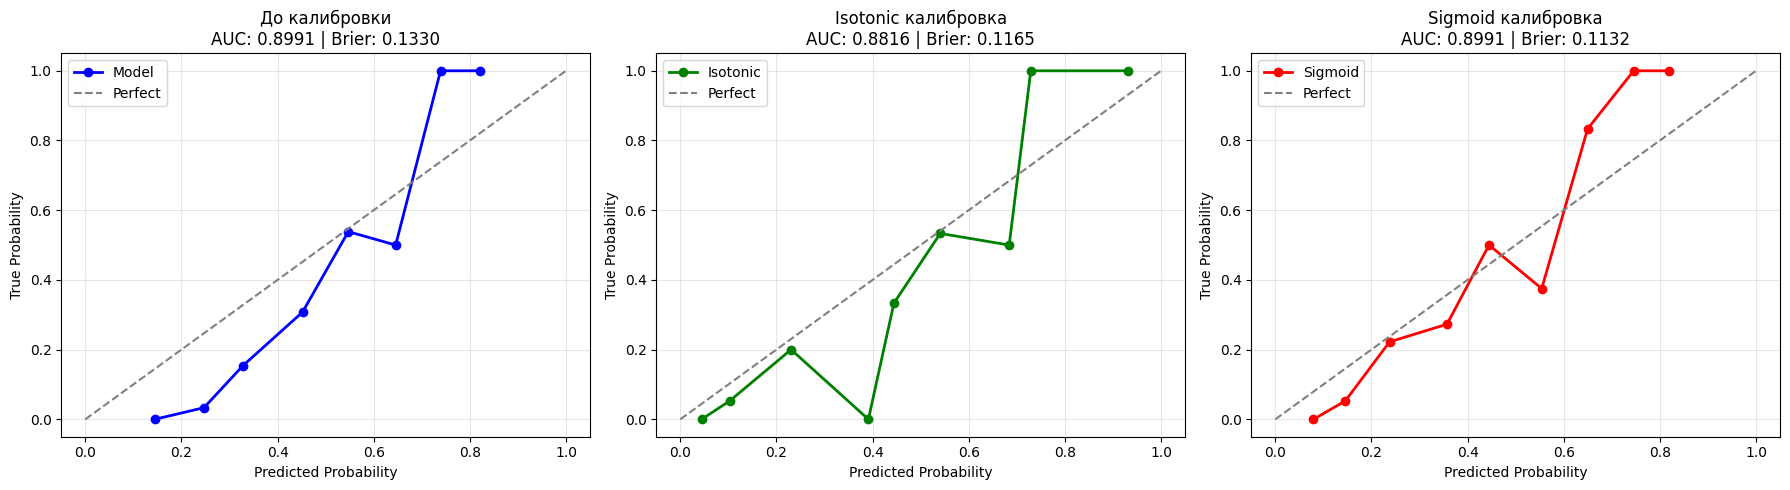


--------------------------------------------------------------------------------
ЗАВЕРШЕНО
--------------------------------------------------------------------------------

Финальные результаты сохранены: /content/drive/MyDrive/data/B/final_results.pkl


In [ ]:
final_results = try_catboost(train_data, base=base)

In [ ]:
final_results['fold_checkpoints'][4]

{'best_params': {'learning_rate': np.float64(0.13736492528089375),
  'l2_leaf_reg': np.float64(15.918343266467259),
  'bagging_temperature': np.float64(0.19967378215835974),
  'random_strength': np.float64(1.0284688768272232),
  'depth': 5,
  'min_data_in_leaf': 1,
  'rsm': np.float64(0.738363234600959),
  'target_border': np.float64(0.5511572371061875)},
 'best_config': {'loss_function': 'Logloss',
  'grow_policy': 'Depthwise',
  'iterations': 29},
 'best_score': np.float64(0.905094094743673),
 'model': <catboost.core.CatBoostClassifier at 0x7da2adc551f0>,
 'timestamp': '2025-11-12 13:58:49'}

In [ ]:
def test_catboost(train_data, test_data, FOLD_CHECKPOINTS=None, base='./checkpoints'):
    # Создаем директорию для чекпойнтов
    os.makedirs(base, exist_ok=True)
    checkpoint_path = os.path.join(base, 'catboost_checkpoint.pkl')

    try:
        X_train, y_train = train_data.drop('target', axis=1).to_numpy(), train_data['target'].to_numpy()
        n_features = X_train.shape[1]
        X_test = test_data.to_numpy()

        kf = StratifiedKFold(n_splits=6, shuffle=True, random_state=42)

        if FOLD_CHECKPOINTS is None:
            # ЕСЛИ ЕСТЬ FOLD_CHECKPOINTS, ТО ПОИСК ЛУЧШИХ ГИПЕРПАРАМЕТРОВ НЕ НУЖЕН
            # Конфигурация поиска
            losses = ['Logloss', 'CrossEntropy']
            grow_policies = ['SymmetricTree', 'Lossguide', 'Depthwise']

            best_score = -np.inf
            best_config = None

            # Счетчики для логирования прогресса
            total_iterations = len(losses) * len(grow_policies) * kf.get_n_splits()
            current_iteration = 0

            print(f"Начало оптимизации: {datetime.now().strftime('%H:%M:%S')}")
            print(f"Всего конфигураций: {total_iterations}")
            print(f"Количество признаков: {n_features}")
            print(f"RSM диапазон: [{1 / (n_features ** 0.5):.3f}, 1.0]")
            print("-" * 80)

            # Кросс-валидация
            FOLD_CHECKPOINTS = []
            for fold_idx, (train_idx, val_idx) in enumerate(kf.split(X_train)):
                # Создаем fold из X_train/y_train
                X_fold_train, X_fold_val = X_train[train_idx], X_train[val_idx]
                y_fold_train, y_fold_val = y_train[train_idx], y_train[val_idx]

                train_pool = Pool(X_fold_train, y_fold_train)
                val_pool = Pool(X_fold_val, y_fold_val)

                fold_best_score = -np.inf
                fold_best_params = None
                fold_best_config = None

                for loss_func in losses:
                    for grow_policy in grow_policies:
                        current_iteration += 1

                        print(f"\n[{current_iteration}/{total_iterations}] "
                              f"Fold {fold_idx+1}/5 | Loss: {loss_func} | Policy: {grow_policy}")
                        print(f"Время: {datetime.now().strftime('%H:%M:%S')}")

                        # Параметры для оптимизации
                        pbounds = {
                            'learning_rate': (1e-3, 3e-1),
                            'l2_leaf_reg': (1, 20),
                            'bagging_temperature': (0, 1),
                            'random_strength': (0, 2),
                            'depth': (3, 8),
                            'min_data_in_leaf': (1, 20),
                            'rsm': (1 / (n_features ** 0.5), 1.0),
                        }

                        if grow_policy == 'Lossguide':
                            pbounds['max_leaves'] = (10, 64)
                        if loss_func=='Logloss':
                            pbounds['target_border'] = (0.5, 0.8)

                        # Objective функция для байесовской оптимизации
                        def objective(**params):
                            # Приводим к целым числам где нужно
                            model_params = {
                                'depth': int(params['depth']),
                                'min_data_in_leaf': int(params['min_data_in_leaf']),
                                'l2_leaf_reg': params['l2_leaf_reg'],
                                'rsm': params['rsm'],
                                'iterations': 2000,
                                'learning_rate':params['learning_rate'],
                                'bootstrap_type':'Bayesian',
                                'bagging_temperature':params['bagging_temperature'],
                                'loss_function':loss_func,
                                'eval_metric':'AUC',
                                'cat_features':[],
                                'random_strength':params['random_strength'],
                                'grow_policy':grow_policy,
                                'nan_mode':'Min',
                                'od_type':'Iter',
                                'od_wait':10,
                                'use_best_model':True,
                                'task_type':'CPU',
                                'random_seed':42,
                                'verbose':False
                            }
                            if grow_policy == 'Lossguide':
                                model_params['max_leaves'] = int(params['max_leaves'])
                            if loss_func == 'Logloss':
                                model_params['auto_class_weights'] = 'Balanced'
                                model_params['target_border'] = params['target_border']

                            model = CatBoostClassifier(**model_params)

                            model.fit(train_pool, eval_set=val_pool)

                            # Предсказание и ROC AUC
                            y_pred_proba = model.predict_proba(X_fold_val)[:, 1]
                            auc = roc_auc_score(y_fold_val, y_pred_proba)

                            return auc

                        # Байесовская оптимизация
                        optimizer = BayesianOptimization(
                            f=objective,
                            pbounds=pbounds,
                            random_state=42,
                            verbose=0
                        )

                        optimizer.maximize(init_points=10, n_iter=50)

                        # Получаем лучшие параметры для этой комбинации
                        this_best_params = optimizer.max['params']
                        this_best_params['depth'] = int(this_best_params['depth'])
                        this_best_params['min_data_in_leaf'] = int(this_best_params['min_data_in_leaf'])
                        if grow_policy == 'Lossguide':
                            this_best_params['max_leaves'] = int(this_best_params['max_leaves'])

                        # Переобучаем модель на лучших параметрах, чтобы получить best_iteration
                        model_params = {
                            'depth': this_best_params['depth'],
                            'min_data_in_leaf': this_best_params['min_data_in_leaf'],
                            'l2_leaf_reg': this_best_params['l2_leaf_reg'],
                            'rsm': this_best_params['rsm'],
                            'iterations': 2000,
                            'learning_rate': this_best_params['learning_rate'],
                            'bootstrap_type':'Bayesian',
                            'bagging_temperature': this_best_params['bagging_temperature'],
                            'loss_function': loss_func,
                            'eval_metric':'AUC',
                            'cat_features':[],
                            'random_strength': this_best_params['random_strength'],
                            'grow_policy': grow_policy,
                            'nan_mode':'Min',
                            'od_type':'Iter',
                            'od_wait':10,
                            'use_best_model':True,
                            'task_type':'CPU',
                            'random_seed':42,
                            'verbose':False
                        }
                        if grow_policy =='Lossguide':
                            model_params['max_leaves'] = this_best_params['max_leaves']
                        if loss_func == 'Logloss':
                            model_params['auto_class_weights'] = 'Balanced'
                            model_params['target_border'] = this_best_params['target_border']

                        model = CatBoostClassifier(**model_params)
                        model.fit(train_pool, eval_set=val_pool)
                        best_iteration = model.get_best_iteration() or 2000

                        y_pred_proba = model.predict_proba(X_fold_val)[:, 1]
                        this_score = roc_auc_score(y_fold_val, y_pred_proba)

                        # Логирование результатов
                        print(f"  Best AUC for this combo: {this_score:.5f}")

                        # Обновляем лучшие для фолда
                        if this_score > fold_best_score:
                            fold_best_score = this_score
                            fold_best_params = this_best_params.copy()
                            fold_best_config = {
                                'loss_function': loss_func,
                                'grow_policy': grow_policy,
                                'iterations': best_iteration
                            }
                            print(f"  ★ Новый лучший результат для фолда! AUC: {fold_best_score:.5f}")

                # Теперь обучаем модель на fold_train с лучшими параметрами (без валидации)
                fold_params = {
                    'iterations': fold_best_config['iterations'],
                    'learning_rate': fold_best_params['learning_rate'],
                    'depth': fold_best_params['depth'],
                    'l2_leaf_reg': fold_best_params['l2_leaf_reg'],
                    'rsm': fold_best_params['rsm'],
                    'bootstrap_type': 'Bayesian',
                    'bagging_temperature': fold_best_params['bagging_temperature'],
                    'loss_function': fold_best_config['loss_function'],
                    'eval_metric': 'AUC',
                    'cat_features': [],
                    'min_data_in_leaf': fold_best_params['min_data_in_leaf'],
                    'random_strength': fold_best_params['random_strength'],
                    'grow_policy': fold_best_config['grow_policy'],
                    'nan_mode': 'Min',
                    'use_best_model': False,
                    'task_type': 'CPU',
                    'random_seed': 42,
                    'verbose': False
                }

                if fold_best_config['grow_policy'] == 'Lossguide':
                    fold_params['max_leaves'] = fold_best_params['max_leaves']
                if fold_best_config['loss_function'] == 'Logloss':
                    fold_params['auto_class_weights'] = 'Balanced'
                    fold_params['target_border'] = fold_best_params['target_border']

                model = CatBoostClassifier(**fold_params)
                model.fit(X_fold_train, y_fold_train)

                # Сохраняем чекпойнт после фолда
                fold_checkpoint = {
                    'best_params': fold_best_params,
                    'best_config': fold_best_config,
                    'best_score': fold_best_score,
                    'model': model,
                    'timestamp': datetime.now().strftime('%Y-%m-%d %H:%M:%S')
                }
                FOLD_CHECKPOINTS.append(fold_checkpoint)
                with open(checkpoint_path, 'wb') as f:
                    pickle.dump(FOLD_CHECKPOINTS, f)
                    print(f"  Чекпойнт {fold_idx + 1} сохранен: {checkpoint_path}")

            print("\n" + "=" * 80)
            print("КРОСС-ВАЛИДАЦИЯ ЗАВЕРШЕНА")
            avg_cv_score = np.mean([f['best_score'] for f in FOLD_CHECKPOINTS])
            print(f"Средний AUC по фолдам: {avg_cv_score:.5f}")
            print("=" * 80)

        # ========== ТЕСТИРОВАНИЕ НА X_test ==========
        print("\nГенерация предсказаний на тесте...")

        models = [f['model'] for f in FOLD_CHECKPOINTS]
        # ========== ОЦЕНКА ДО КАЛИБРОВКИ ==========
        print("\n" + "-" * 80)
        print("РЕЗУЛЬТАТЫ ДО КАЛИБРОВКИ")
        print("=" * 80)

        y_prob_before = np.mean([m.predict_proba(X_test)[:, 1] for m in models], axis=0)
        print("\nВычисление OOF-предсказаний...")
        oof_probs = np.zeros(len(X_train))
        for fold_idx, (train_idx, val_idx) in enumerate(kf.split(X_train)):
            model = FOLD_CHECKPOINTS[fold_idx]['model']
            X_fold_val = X_train[val_idx]
            oof_probs[val_idx] = model.predict_proba(X_fold_val)[:, 1]

        calib_X = oof_probs.reshape(-1, 1)  # (n_samples, 1)
        calib_y = y_train

        # 2. Sigmoid (Platt Scaling)
        print("\nМетод калибровки: sigmoid")
        sigmoid = LogisticRegression(max_iter=1000, solver='lbfgs')
        sigmoid.fit(calib_X, calib_y)

        y_prob_sig = sigmoid.predict_proba(y_prob_before.reshape(-1, 1))[:, 1]


        final_results =  {
            'c_model': sigmoid,
            'fold_checkpoints': FOLD_CHECKPOINTS,
            'y_pred': y_prob_sig,
        }

        return final_results






    except Exception as e:
        print(f"\n{'='*80}")
        print(f"ОШИБКА: {e}")
        print(f"{'='*80}")

        # Сохраняем состояние при ошибке
        error_checkpoint = {
            'fold_checkpoints': FOLD_CHECKPOINTS if 'FOLD_CHECKPOINTS' in locals() else None,
            'error': str(e),
            'timestamp': datetime.now().strftime('%Y-%m-%d %H:%M:%S')
        }

        error_path = os.path.join(base, 'error_checkpoint.pkl')
        with open(error_path, 'wb') as f:
            pickle.dump(error_checkpoint, f)

        # Также сохраняем в JSON для читаемости
        error_json_path = os.path.join(base, 'error_checkpoint.json')
        json_checkpoint = {
            'fold_checkpoints': [f for f in error_checkpoint['fold_checkpoints']] if error_checkpoint['fold_checkpoints'] else None,  # без моделей для JSON
            'error': error_checkpoint['error'],
            'timestamp': error_checkpoint['timestamp']
        }
        with open(error_json_path, 'w', encoding='utf-8') as f:
            json.dump(json_checkpoint, f, indent=2, ensure_ascii=False)

        print(f"\nЧекпойнт ошибки сохранен:")
        print(f"  - {error_path}")
        print(f"  - {error_json_path}")
        print(f"\nДля возобновления используйте:")
        print(f"  with open('{error_path}', 'rb') as f:")
        print(f"      checkpoint = pickle.load(f)")
        print(f"  try_catboost(train_data, ")
        print(f"               FOLD_CHECKPOINTS=checkpoint['fold_checkpoints'],")

        raise e

In [ ]:
results = test_catboost(train_data, test_data)

Начало оптимизации: 14:28:24
Всего конфигураций: 36
Количество признаков: 9
RSM диапазон: [0.333, 1.0]
--------------------------------------------------------------------------------

[1/36] Fold 1/5 | Loss: Logloss | Policy: SymmetricTree
Время: 14:28:24
  Best AUC for this combo: 0.91333
  ★ Новый лучший результат для фолда! AUC: 0.91333

[2/36] Fold 1/5 | Loss: Logloss | Policy: Lossguide
Время: 14:28:39
  Best AUC for this combo: 0.90686

[3/36] Fold 1/5 | Loss: Logloss | Policy: Depthwise
Время: 14:28:58
  Best AUC for this combo: 0.90952

[4/36] Fold 1/5 | Loss: CrossEntropy | Policy: SymmetricTree
Время: 14:29:15
  Best AUC for this combo: 0.90895

[5/36] Fold 1/5 | Loss: CrossEntropy | Policy: Lossguide
Время: 14:29:34
  Best AUC for this combo: 0.90857

[6/36] Fold 1/5 | Loss: CrossEntropy | Policy: Depthwise
Время: 14:29:55
  Best AUC for this combo: 0.90724
  Чекпойнт 1 сохранен: ./checkpoints/catboost_checkpoint.pkl

[7/36] Fold 2/5 | Loss: Logloss | Policy: SymmetricTree


In [ ]:
best_fold = {'best_score': 0}
for fold in results['fold_checkpoints']:
    if fold['best_score'] > best_fold['best_score']:
        best_fold = fold

print(best_fold)

{'best_params': {'learning_rate': np.float64(0.22242676376655668), 'l2_leaf_reg': np.float64(6.4070562643823825), 'bagging_temperature': np.float64(0.2113600419135239), 'random_strength': np.float64(0.6814406715555431), 'depth': 3, 'min_data_in_leaf': 16, 'rsm': np.float64(0.8153632294445348), 'target_border': np.float64(0.6823738152853334)}, 'best_config': {'loss_function': 'Logloss', 'grow_policy': 'SymmetricTree', 'iterations': 55}, 'best_score': np.float64(0.9228727556596409), 'model': <catboost.core.CatBoostClassifier object at 0x7da2adc54050>, 'timestamp': '2025-11-12 14:44:39'}


In [ ]:
fold_best_config = best_fold['best_config']
fold_best_params = best_fold['best_params']

In [ ]:
fold_best_config

{'loss_function': 'Logloss', 'grow_policy': 'SymmetricTree', 'iterations': 55}

## Вот это сработало на 100 баллов

In [ ]:
fold_params = {
                    'iterations': fold_best_config['iterations'],
                    'learning_rate': fold_best_params['learning_rate'],
                    'depth': fold_best_params['depth'],
                    'l2_leaf_reg': fold_best_params['l2_leaf_reg'],
                    'rsm': fold_best_params['rsm'],
                    'bootstrap_type': 'Bayesian',
                    'bagging_temperature': fold_best_params['bagging_temperature'],
                    'loss_function': fold_best_config['loss_function'],
                    'eval_metric': 'AUC',
                    'cat_features': [],
                    'min_data_in_leaf': fold_best_params['min_data_in_leaf'],
                    'random_strength': fold_best_params['random_strength'],
                    'grow_policy': fold_best_config['grow_policy'],
                    'nan_mode': 'Min',
                    'use_best_model': False,
                    'task_type': 'CPU',
                    'random_seed': 42,
                    'verbose': True
                }

if fold_best_config['grow_policy'] == 'Lossguide':
    fold_params['max_leaves'] = fold_best_params['max_leaves']
if fold_best_config['loss_function'] == 'Logloss':
    fold_params['auto_class_weights'] = 'Balanced'
    fold_params['target_border'] = fold_best_params['target_border']

X_train, y_train = train_data.drop('target', axis=1).to_numpy(), train_data['target'].to_numpy()
X_test = test_data.to_numpy()
model = CatBoostClassifier(**fold_params)
model.fit(X_train, y_train)


y_prob_before = model.predict_proba(X_test)[:, 1]

0:	total: 565us	remaining: 30.6ms
1:	total: 1.33ms	remaining: 35.4ms
2:	total: 1.84ms	remaining: 31.8ms
3:	total: 2.27ms	remaining: 28.9ms
4:	total: 2.68ms	remaining: 26.8ms
5:	total: 3.13ms	remaining: 25.6ms
6:	total: 3.57ms	remaining: 24.5ms
7:	total: 3.99ms	remaining: 23.4ms
8:	total: 4.38ms	remaining: 22.4ms
9:	total: 4.79ms	remaining: 21.6ms
10:	total: 5.2ms	remaining: 20.8ms
11:	total: 5.61ms	remaining: 20.1ms
12:	total: 6.06ms	remaining: 19.6ms
13:	total: 6.42ms	remaining: 18.8ms
14:	total: 6.83ms	remaining: 18.2ms
15:	total: 7.29ms	remaining: 17.8ms
16:	total: 7.69ms	remaining: 17.2ms
17:	total: 8.09ms	remaining: 16.6ms
18:	total: 8.48ms	remaining: 16.1ms
19:	total: 8.92ms	remaining: 15.6ms
20:	total: 9.32ms	remaining: 15.1ms
21:	total: 9.79ms	remaining: 14.7ms
22:	total: 10.2ms	remaining: 14.2ms
23:	total: 10.7ms	remaining: 13.8ms
24:	total: 11.1ms	remaining: 13.3ms
25:	total: 11.5ms	remaining: 12.8ms
26:	total: 11.9ms	remaining: 12.3ms
27:	total: 12.3ms	remaining: 11.8ms
28:	

In [ ]:
# answer = pd.DataFrame({'target': results['y_pred']})
answer = pd.DataFrame({'target': y_prob_before})

In [ ]:
answer.head()

,target
0,0.124965
1,0.085137
2,0.089157
3,0.074502
4,0.037717


In [ ]:
answer.to_csv('answers.csv', index=False)